# General performance


Run from the repository root or from `notebooks/`. The values are computed from the aggregated
results in `results/*-aggregated-0-bullet-is.csv` and the per-run predictions under
`$REASONANCE_RESULTS_ROOT`, and cached in `results/pair-values/` (`refresh=True` recomputes).
Figures are only shown here (`save=False`); pass `save=True` to write them to
`results/figures/paper/`.

Paper figures in this notebook (appendix), after the coverage of the data they are computed on:

- `fig:appendix-general-accuracy-all-tasks`
- `fig:appendix-general-risk-scores-all-tasks`
- `fig:appendix-length-token-distributions-by-effort-all-tasks`

In [1]:
import os
from pathlib import Path

# every path in `reasonance` is relative to the repository root
if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)

import matplotlib.pyplot as plt
from reasonance.paper_figures import accuracy_by_task, effort_vs_length, risk_scores
from reasonance.plotting import set_figure_prefix, set_plot_style

QA_MODE = "numeric"
set_plot_style()
set_figure_prefix(QA_MODE)  # the tasks are panels, so only the QA mode is in the file name

('numeric',)

## Coverage

How many individuals the figures are computed on, and what was lost getting there. Figures restrict
to the individuals *every* run has an answer for, so one run missing a person removes that person
from all runs. In the table:

- `no_answer`: individuals dropped because a run returned nothing. A reasoning model that spends its
  whole budget on the trace never states an answer, and it does so on the individuals it deliberates
  longest about, so these drops are not missing at random.
- `forced_cells`: answers obtained by closing the trace and asking the model to commit. They are
  included in the figures, but they are a different condition from the original run.
- the legend printed below the table explains every column.

In [2]:
from reasonance.analysis import print_coverage

coverage = print_coverage(qa_mode=QA_MODE)

Individuals behind every figure in this notebook
         task  runs  individuals  covered  used  no_answer  complete_pct  cells  retry_cells  truncated_cells  forced_cells  retry_pct  truncated_pct  forced_individuals  without_retries
ACSEmployment   108        16181     5000  4998          2         100.0 539784         5905             5235            11       1.09           0.97                  11             4327
    ACSIncome   108         8323     8323  8305         18          99.8 896940        17986            14475           100       2.01           1.61                  98             5591
         SIPP   108         3972     3972  3966          6          99.8 428328        14632            11855           146       3.42           2.77                 129             1980

  covered    = individuals every run evaluated -- the effective task size. Below
               `individuals` when runs used different test-set sizes (a 5000-row run
               beside a 16181-row on

## Accuracy per task

Paper: `fig:appendix-general-accuracy-all-tasks`.

One row per model, one dot per effort level, error bars the spread across generation seeds.
References per task: the XGBoost baseline (solid) and the Rashomon cutoff (dashed), 0.05 below the
best model in that task. x ranges are per task -- base rates differ, so positions are not
comparable across panels; the model rows are.

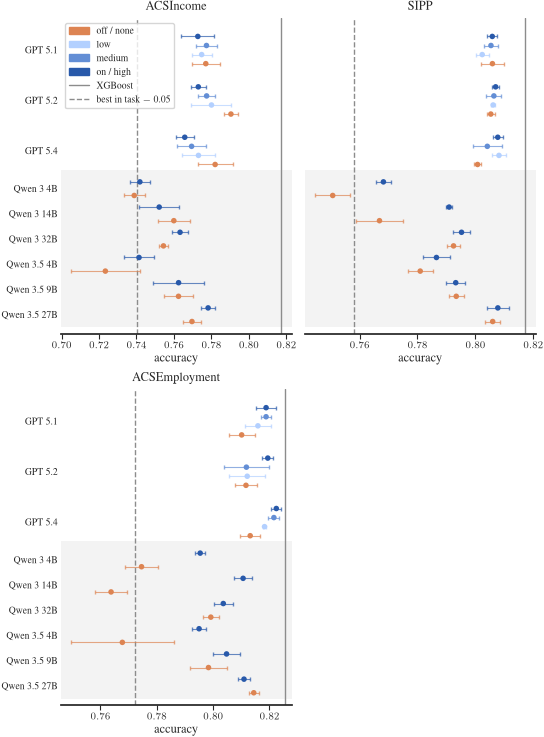

In [3]:
accuracy_by_task(orient="h", save=False)
plt.show()

## Risk score distributions

Paper: `fig:appendix-general-risk-scores-all-tasks`.

Numeric QA asks for a probability, so these distributions are the raw material of every number
elsewhere. One panel per task, the mean over runs of each group's risk-score histogram (matched
runs only, OpenAI at `none`/`high`, so both groups hold the same number of runs).

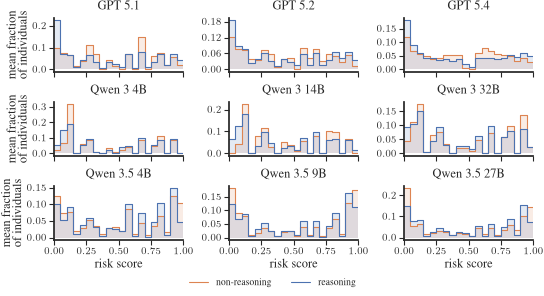

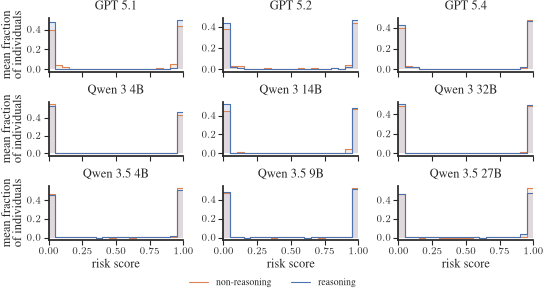

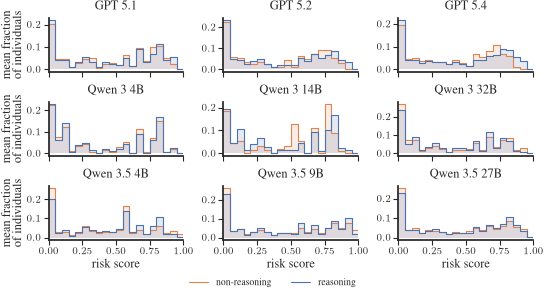

In [4]:
risk_scores(save=False)
plt.show()

## Effort vs. realized reasoning length

Paper: `fig:appendix-length-token-distributions-by-effort-all-tasks`.

One panel per model and task, one histogram per effort setting over the realized reasoning tokens
(log x, shared across all panels so the settings are comparable between models). The off setting is
left out: it produces no trace by construction. The in-panel note gives the largest count in the
panel and the share of traces of zero length despite reasoning being on. One 3x3 grid per task.

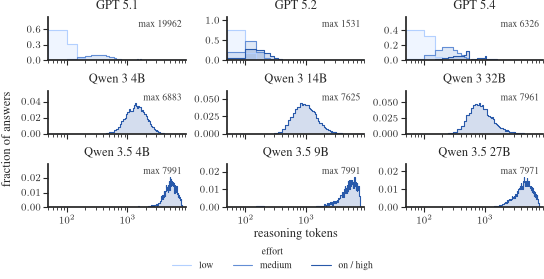

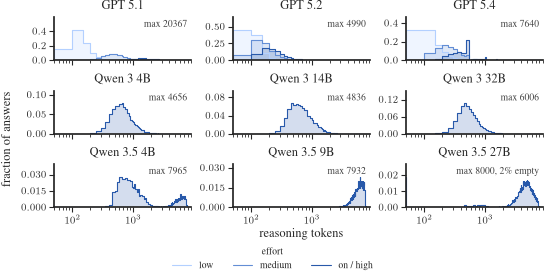

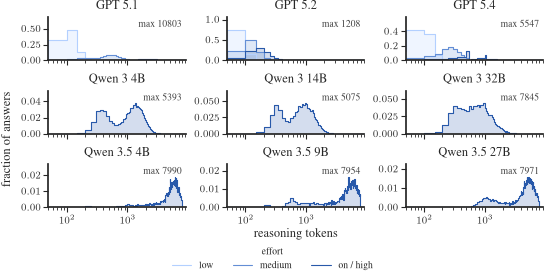

In [5]:
effort_vs_length(refresh=True, save=False)
plt.show()